# 1. Mengapa Preprocessing Diperlukan?
Preprocessing merupakan tahapan untuk mempersiapkan data sebelum digunakan dalam proses pelatihan model Convolutional Neural Network (CNN).

Berdasarkan hasil Explanatory Data Analysis (EDA), ditemukan bahwa:
- Dataset memiliki ukuran gambar yang bervariasi.
- Seluruh gambar menggunakan format RGB.
- Dataset terduru daru empat kelas klasifikasi.

Oleh karena itu, diperlukan beberapa proses preprocessing agar seluruh citra memiliki format yang seragam dan siap digunakan oleh model CNN.

# 2. Import Library

In [1]:
from pathlib import Path
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# 3. Configuration

In [2]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [3]:
from settings.config import *

# 4. Load Dataset Path

In [4]:
DATASET_PATH = Path("../Dataset")

TRAIN_PATH = DATASET_PATH / "Training"
TEST_PATH = DATASET_PATH / "Testing"

In [5]:
print("Training :", TRAIN_PATH.exists())
print("Testing  :", TEST_PATH.exists())

Training : True
Testing  : True


# 5. Calculate Dataset Mean & STD

In [6]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [7]:
stat_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor()
])

In [8]:
train_dataset = ImageFolder(
    root=TRAIN_PATH,
    transform=stat_transform
)

In [9]:
# Create DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [10]:
channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_pixels = 0

In [11]:
# Calculating mean and std
channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_pixels = 0

for images, _ in train_loader:
    # images shape: [batch_size, 3, 224, 224]
    channel_sum += images.sum(dim=(0, 2, 3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))
    num_pixels += images.size(0) * images.size(2) * images.size(3)
mean = channel_sum / num_pixels
std = torch.sqrt((channel_squared_sum / num_pixels) - (mean ** 2))


print(f"Mean : {mean}")
print(f"Std  : {std}")

Mean : tensor([0.1794, 0.1794, 0.1794])
Std  : tensor([0.1868, 0.1868, 0.1868])


In [12]:
image, _ = train_dataset[0]

print(torch.equal(image[0], image[1]))
print(torch.equal(image[1], image[2]))

True
True


Meskipun dataset disimpan dalam format RGB, ketiga channel memiliki distribusi yang identik. Hal ini menunjukkan bahwa citra kemungkinan berasal dari grayscale yang direplikasi ke tiga channel RGB. Oleh karena itu, nilai mean dan standar deviasi untuk ketiga channel juga identik.

# 6. Define Preprocessing Pipeline

In [13]:
# Proses Preprocessing untuk data training
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5), # angka 0.5 dipilih agar peluang gambar dibalik atau dibiarkan seperti semula masing-masing 50% 
    transforms.RandomRotation(degrees=10), # angka 10 dipilih agar gambar dirotasi dengan ukuran derajat yang kecil sehingga gambar hasil mri masih masuk akal
    transforms.ToTensor(),
    transforms.Normalize(
        mean=DATASET_MEAN,
        std=DATASET_STD
    )
])

In [14]:
# Proses Preprocessing untuk data testing
# Dibedakan dengan training karena pada proses preprocessing data testing tidak ada augmentasi

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=DATASET_MEAN,
        std=DATASET_STD
    )
])

# 7. Create Final Dataset

In [15]:
train_dataset = ImageFolder(
    root=TRAIN_PATH,
    transform=train_transform
)

test_dataset = ImageFolder(
    root=TEST_PATH,
    transform=test_transform
)

print(f"Training Images : {len(train_dataset)}")
print(f"Testing Images  : {len(test_dataset)}")

Training Images : 2870
Testing Images  : 394


# 8. Create Final DataLoader

In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 9. Validation

In [17]:
images, labels = next(iter(train_loader))

print("Image Batch Shape :", images.shape)
print("Label Batch Shape :", labels.shape)

print("\nMinimum Pixel Value :", images.min().item())
print("Maximum Pixel Value :", images.max().item())

Image Batch Shape : torch.Size([64, 3, 224, 224])
Label Batch Shape : torch.Size([64])

Minimum Pixel Value : -0.9603853821754456
Maximum Pixel Value : 4.3929338455200195


In [18]:
# Class Mapping
print(train_dataset.class_to_idx)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


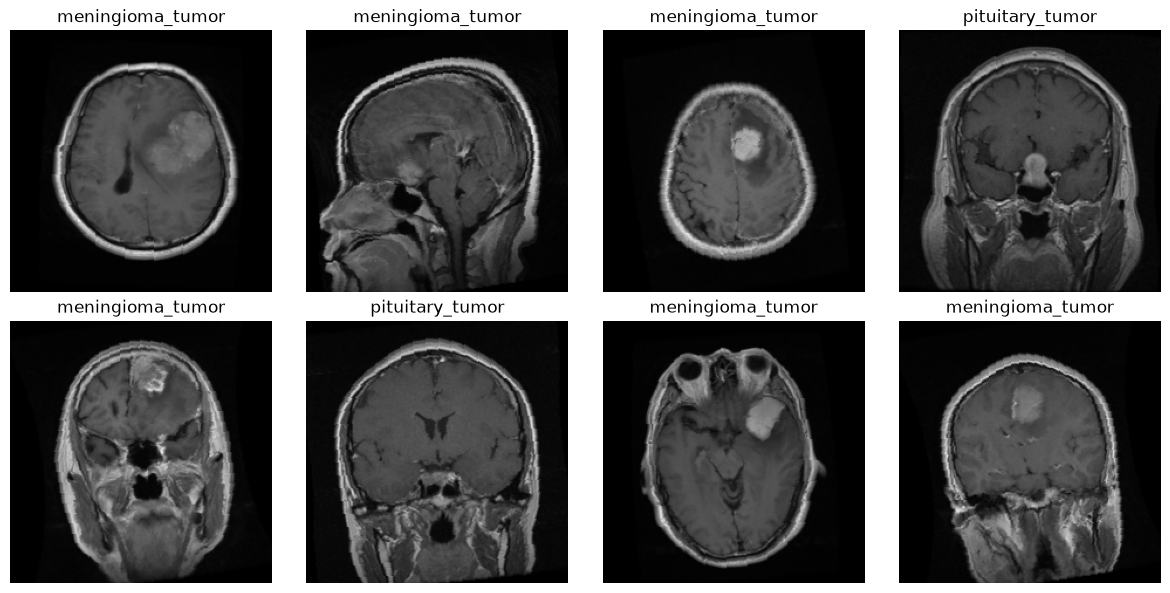

In [19]:
# Menampilkan gambar hasil preprocessing
import numpy as np

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12,6))
for i, ax in enumerate(axes.flatten()):
    image = images[i].permute(1,2,0).numpy()
    image = image * DATASET_STD + DATASET_MEAN
    image = np.clip(image,0,1)
    ax.imshow(image)
    ax.set_title(list(train_dataset.class_to_idx.keys())[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()